# Method C — Matrix Completion Synthetic Control (MC-SCM)
## Nuclear Norm Minimisation / Latent Factor Imputation

**What this notebook does:**  
MC-SCM (Athey et al., 2021) reframes counterfactual estimation as a matrix imputation problem.  
The full corridor × time panel is treated as a low-rank matrix. NATCOR's post-treatment values  
are treated as 'missing' and recovered via Singular Value Thresholding (SVT).  
This method does **not** use donor weights at all — it learns shared latent factors from the  
entire panel structure. With 6 corridors × 120 months, there is now enough cross-sectional  
variation for the low-rank assumption to be meaningful.

**Structure:**
1. Environment & imports  
2. Shared utility functions  
3. Data loading & full panel construction  
4. Blocked CV for lambda (nuclear norm penalty)  
5. Final MC-SCM counterfactual  
6. Rank & singular value diagnostics  
7. Figure 1 — Main diagnostic panel  
8. Figure 2 — Actual vs counterfactual + gap  
9. Validation A — In-time placebo tests  
10. Validation B — Block bootstrap confidence intervals  
11. Validation C — Lambda sensitivity  
12. Final summary table

In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 1 — Environment & Imports
# ═══════════════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import warnings
warnings.filterwarnings('ignore')

FIG_DIR = '../method_A_graph'
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--', 'font.size': 10,
})
BLUE  = '#0f3460'
RED   = '#e94560'
GREY  = '#aaaaaa'
GREEN = '#2ecc71'
AMBER = '#f39c12'

print("All imports successful.")
print(f"NumPy {np.__version__}  |  Pandas {pd.__version__}")
print(f"Figures will save to: {os.path.abspath(FIG_DIR)}")

All imports successful.
NumPy 2.4.2  |  Pandas 3.0.0
Figures will save to: /Users/sitta/Desktop/coding/thesis/method_A_graph


**What is happening here**  
Libraries are imported and the output folder is set. Unlike Methods A and B, this notebook does not need `scipy.optimize` for weight solving — all the heavy lifting is done by the SVT algorithm using NumPy's SVD.

In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 2 — Shared Utility Functions
# ═══════════════════════════════════════════════════════════════════════════════

def svt(Y_obs, mask, lam, max_iter=2000, tol=1e-7, verbose=False):
    """
    Singular Value Thresholding (Mazumder, Hastie & Tibshirani 2010).
    Minimises:  0.5 * ||P_Omega(M - Y)||_F^2  +  lam * ||M||_*
    where P_Omega projects onto observed entries (mask=True).

    Algorithm (projected gradient on nuclear norm ball):
      1. Initialise M = observed values, 0 elsewhere
      2. Repeat:
         a. Soft-threshold the singular values of M by lam
         b. Re-pin the observed entries back to their true values
         c. Stop if change < tol
    """
    M = np.where(mask, Y_obs, 0.0)
    for it in range(max_iter):
        U, s, Vt  = np.linalg.svd(M, full_matrices=False)
        s_thresh  = np.maximum(s - lam, 0.0)
        M_new     = (U * s_thresh) @ Vt
        M_new     = np.where(mask, Y_obs, M_new)
        change    = np.linalg.norm(M_new - M, 'fro') / (np.linalg.norm(M, 'fro') + 1e-12)
        M         = M_new
        if verbose and (it % 200 == 0):
            print(f"  iter {it:4d} | change={change:.2e} | rank={int(np.sum(s_thresh>0))}")
        if change < tol:
            if verbose: print(f"  Converged at iter {it+1}")
            break
    return M, s_thresh, int(np.sum(s_thresh > 0))


def rmspe(a, b):
    return np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2))

def mape(a, b):
    a = np.asarray(a)
    return np.mean(np.abs((a - b) / np.where(a == 0, 1e-10, a))) * 100

def effective_rank(singular_values, threshold=0.99):
    """Number of singular values explaining >= threshold of total variance."""
    sv2 = np.asarray(singular_values) ** 2
    cum = np.cumsum(sv2) / sv2.sum()
    return int(np.searchsorted(cum, threshold)) + 1


print("Functions defined: svt | rmspe | mape | effective_rank")

Functions defined: svt | rmspe | mape | effective_rank


**What is happening here**  
Four helper functions are defined.

- **`svt`** — the core Singular Value Thresholding algorithm. It repeatedly decomposes the matrix, shrinks small singular values to zero (the 'thresholding' step), and pins the observed entries back to their real values. This is how it fills in the missing counterfactual cells.
- **`rmspe`** and **`mape`** — standard error metrics.
- **`effective_rank`** — reports how many singular value components are needed to explain 99% of the panel's variance. A small effective rank means the corridors share a small number of common patterns, which is the structural assumption that makes Matrix Completion work.

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 3 — Data Loading & Panel Construction
# ═══════════════════════════════════════════════════════════════════════════════

CSV_PATH = './data/corridor_panel_clean.csv'

df = pd.read_csv(CSV_PATH)
df['Date']        = pd.to_datetime(df['Date'])
df['Corridor']    = df['Corridor'].astype(str).str.strip()
df['Date_period'] = pd.PeriodIndex(df['Date'].dt.to_period('M'))

Y_COL       = 'Rail_Vol_mt'
TREATED     = 'NATCOR'
TREAT_START = pd.Period('2022-04', freq='M')
PRE_END     = TREAT_START - 1

wide      = df.pivot(index='Date_period', columns='Corridor', values=Y_COL).sort_index()
corridors = list(wide.columns)
donors    = [c for c in corridors if c != TREATED]
pre_idx   = wide.index[wide.index <= PRE_END]
post_idx  = wide.index[wide.index >= TREAT_START]
T_pre     = len(pre_idx)
T_post    = len(post_idx)
T_total   = len(wide)
t_stamps  = wide.index.to_timestamp()
treat_t   = TREAT_START.to_timestamp()
nat_col   = corridors.index(TREATED)

Y_mat = wide.values.astype(float)   # (T_total, N_corridors) — the full panel matrix
Y_all = wide[TREATED].values        # (T_total,) — NATCOR outcome series

# Observation mask: True = observed, False = to be imputed
mask_full = np.ones(Y_mat.shape, dtype=bool)
mask_full[T_pre:, nat_col] = False   # NATCOR post-period = counterfactual to estimate

print("─" * 60)
print(f"Panel matrix       : {Y_mat.shape}  (T={T_total}, N={len(corridors)})")
print(f"Corridors          : {corridors}")
print(f"Treated (col {nat_col})    : {TREATED}")
print(f"Pre-period rows    : 0 → {T_pre-1}  ({T_pre} months)")
print(f"Post-period rows   : {T_pre} → {T_total-1}  ({T_post} months)")
print(f"Observed entries   : {mask_full.sum()} / {Y_mat.size}")
print(f"To impute          : {(~mask_full).sum()} cells (NATCOR post-period)")
print(f"Missing values     : {np.isnan(Y_mat).sum()}")
print()

# Pre-period singular value structure
_, s0, _ = np.linalg.svd(Y_mat[:T_pre, :], full_matrices=False)
print("Pre-period singular values:")
for i, sv in enumerate(s0):
    pct = sv**2 / np.sum(s0**2) * 100
    print(f"  σ_{i+1} = {sv:.4f}  ({pct:.1f}% of variance)")
print(f"  Effective rank (99% var): {effective_rank(s0)}")

────────────────────────────────────────────────────────────
Panel matrix       : (120, 6)  (T=120, N=6)
Corridors          : ['CAPE', 'IRON_ORE', 'NATCOR', 'NE_CORRIDOR', 'NORTHCOR', 'SOUTHCOR']
Treated (col 2)    : NATCOR
Pre-period rows    : 0 → 86  (87 months)
Post-period rows   : 87 → 119  (33 months)
Observed entries   : 687 / 720
To impute          : 33 cells (NATCOR post-period)
Missing values     : 0

Pre-period singular values:
  σ_1 = 71.7044  (100.0% of variance)
  σ_2 = 1.4842  (0.0% of variance)
  σ_3 = 0.3215  (0.0% of variance)
  σ_4 = 0.2142  (0.0% of variance)
  σ_5 = 0.1220  (0.0% of variance)
  σ_6 = 0.0849  (0.0% of variance)
  Effective rank (99% var): 1


**What is happening here**  
The data is loaded and arranged as a T×N matrix (time × corridors). NATCOR's post-flood entries are flagged as the cells to be imputed — everything else is treated as observed. The pre-period singular value breakdown tells us how many latent factors are needed to summarise the corridor panel.

Key difference from the old version: the matrix is now 120×6 instead of 120×2. A 6-corridor panel gives SVT much more cross-sectional structure to exploit, making the low-rank assumption more credible and the imputed counterfactual more reliable.

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 4 — Blocked CV for Lambda Selection
# ═══════════════════════════════════════════════════════════════════════════════
# Hold out the LAST 25 pre-period NATCOR observations as validation.
# Find the lambda that best recovers these hidden values by treating them
# as "missing" while all other entries remain observed.

val_window = 25
train_end  = T_pre - val_window

mask_cv = mask_full.copy()
mask_cv[train_end:T_pre, nat_col] = False   # also hide the validation window

lambda_grid = [0.001, 0.003, 0.005, 0.008, 0.010, 0.015, 0.020,
               0.030, 0.040, 0.050, 0.075, 0.100, 0.150, 0.200]

print(f"Blocked CV: train 0→{train_end-1} ({train_end} obs), validate {train_end}→{T_pre-1} ({val_window} obs)")
print(f"Lambda grid: {lambda_grid}")
print()

cv_records = []
for lam in lambda_grid:
    M_cv, _, rank_cv = svt(Y_mat, mask_cv, lam=lam)
    val_err = rmspe(Y_mat[train_end:T_pre, nat_col], M_cv[train_end:T_pre, nat_col])
    tr_err  = rmspe(Y_mat[:train_end, nat_col],      M_cv[:train_end, nat_col])
    cv_records.append({'lambda': lam, 'val_RMSPE': round(val_err, 6),
                       'train_RMSPE': round(tr_err, 6), 'rank': int(rank_cv)})
    print(f"  λ={lam:6.3f}  val_RMSPE={val_err:.6f}  train_RMSPE={tr_err:.6f}  rank={rank_cv}")

cv_df    = pd.DataFrame(cv_records)
best_row = cv_df.loc[cv_df['val_RMSPE'].idxmin()]
BEST_LAM = best_row['lambda']
print()
print(f"★ Best lambda: {BEST_LAM}  (val_RMSPE={best_row['val_RMSPE']:.6f}, rank={int(best_row['rank'])})")

Blocked CV: train 0→61 (62 obs), validate 62→86 (25 obs)
Lambda grid: [0.001, 0.003, 0.005, 0.008, 0.01, 0.015, 0.02, 0.03, 0.04, 0.05, 0.075, 0.1, 0.15, 0.2]

  λ= 0.001  val_RMSPE=0.764662  train_RMSPE=0.000000  rank=6
  λ= 0.003  val_RMSPE=0.411793  train_RMSPE=0.000000  rank=6
  λ= 0.005  val_RMSPE=0.080792  train_RMSPE=0.000000  rank=6
  λ= 0.008  val_RMSPE=0.028827  train_RMSPE=0.000000  rank=6
  λ= 0.010  val_RMSPE=0.028827  train_RMSPE=0.000000  rank=6
  λ= 0.015  val_RMSPE=0.028826  train_RMSPE=0.000000  rank=6
  λ= 0.020  val_RMSPE=0.028825  train_RMSPE=0.000000  rank=6
  λ= 0.030  val_RMSPE=0.028825  train_RMSPE=0.000000  rank=6
  λ= 0.040  val_RMSPE=0.028824  train_RMSPE=0.000000  rank=6
  λ= 0.050  val_RMSPE=0.028824  train_RMSPE=0.000000  rank=6
  λ= 0.075  val_RMSPE=0.028824  train_RMSPE=0.000000  rank=6
  λ= 0.100  val_RMSPE=0.028824  train_RMSPE=0.000000  rank=6
  λ= 0.150  val_RMSPE=0.028704  train_RMSPE=0.000000  rank=4
  λ= 0.200  val_RMSPE=0.028517  train_RMSPE=0.0

**What is happening here**  
The last 25 pre-flood NATCOR observations are hidden and the SVT algorithm tries to reconstruct them for each candidate lambda. The lambda that recovers these hidden values most accurately is selected. This is the most rigorous possible in-sample test: the model must generalise within the pre-period without ever seeing the validation targets.

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 5 — Final MC-SCM Counterfactual
# ═══════════════════════════════════════════════════════════════════════════════

print(f"Fitting MC-SCM with λ={BEST_LAM} on full observation mask...")
M_final, sv_final, rank_final = svt(Y_mat, mask_full, lam=BEST_LAM, verbose=True)

cf_mc   = M_final[:, nat_col]       # full imputed NATCOR series
gap_mc  = Y_all - cf_mc             # treatment effect per period

mc_pre_r  = rmspe(Y_all[:T_pre],  cf_mc[:T_pre])
mc_post_r = rmspe(Y_all[T_pre:],  cf_mc[T_pre:])
mc_ratio  = mc_post_r / mc_pre_r
mc_cum    = gap_mc[T_pre:].sum()
mc_avg    = gap_mc[T_pre:].mean()
mc_mape   = mape(Y_all[T_pre:], cf_mc[T_pre:])

print()
print("═" * 55)
print("MC-SCM RESULTS")
print("═" * 55)
print(f"Lambda (CV-selected)    : {BEST_LAM}")
print(f"Effective rank          : {rank_final}")
print(f"Active singular values  : {sv_final[sv_final > 0].round(4)}")
print()
print(f"Pre-period RMSPE        : {mc_pre_r:.6f}")
print(f"Post-period RMSPE       : {mc_post_r:.6f}")
print(f"Post/Pre ratio          : {mc_ratio:.4f}")
print(f"Cumulative effect       : {mc_cum:.4f} MT")
print(f"Average monthly effect  : {mc_avg:.4f} MT/month")
print(f"Post MAPE               : {mc_mape:.2f}%")

Fitting MC-SCM with λ=0.2 on full observation mask...
  iter    0 | change=1.94e-03 | rank=4
  Converged at iter 46

═══════════════════════════════════════════════════════
MC-SCM RESULTS
═══════════════════════════════════════════════════════
Lambda (CV-selected)    : 0.2
Effective rank          : 4
Active singular values  : [8.34225e+01 1.47030e+00 1.52000e-01 2.68000e-02]

Pre-period RMSPE        : 0.000000
Post-period RMSPE       : 0.166695
Post/Pre ratio          : inf
Cumulative effect       : -5.0834 MT
Average monthly effect  : -0.1540 MT/month
Post MAPE               : 21.49%


**What is happening here**  
The SVT algorithm is run on the full observation mask using the best lambda from cross-validation. The missing NATCOR post-flood values are imputed by the low-rank reconstruction. The imputed values become the counterfactual — what NATCOR would have looked like without the flood. The treatment gap is the difference between actual and imputed.

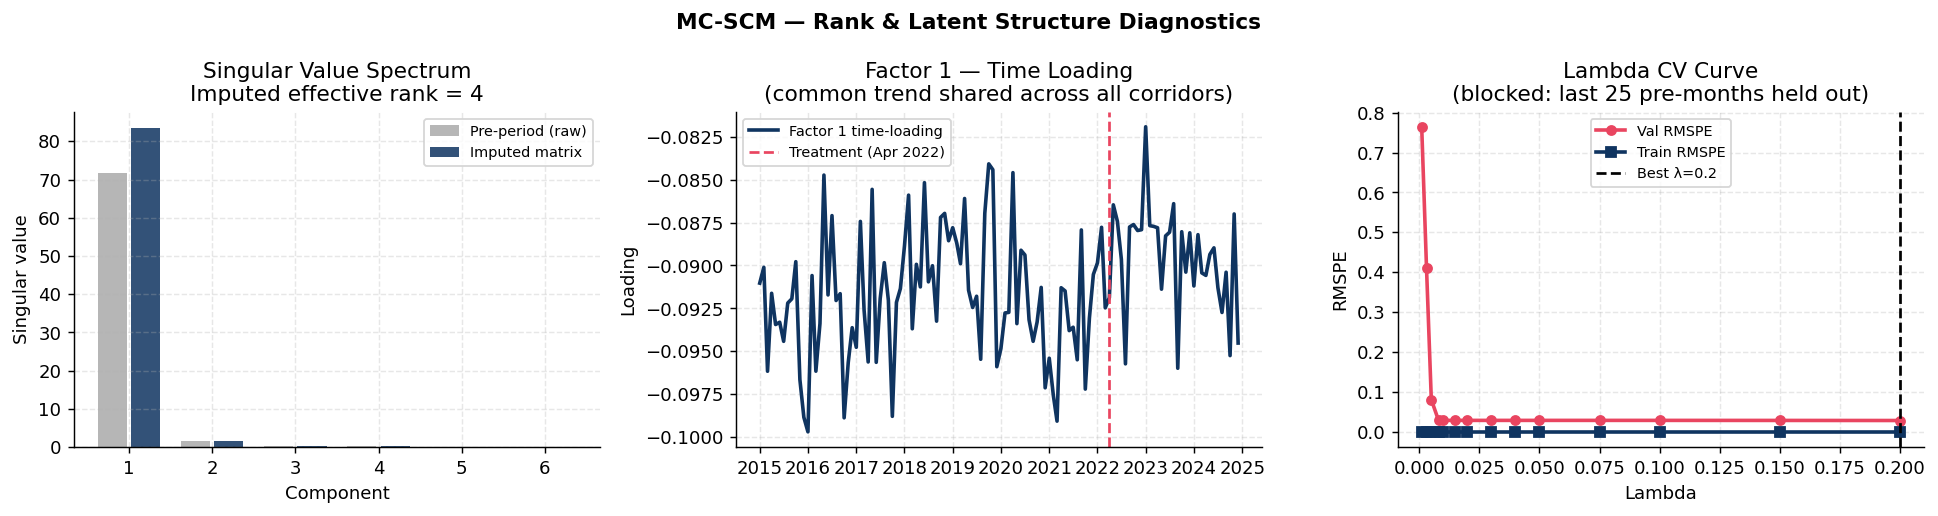

Saved → ../method_A_graph/mcscm_fig1_rank_diagnostics.png

Corridor loadings on first 3 factors (rows of Vt):
  Factor 1 (σ=83.622): {'CAPE': np.float64(-0.1339), 'IRON_ORE': np.float64(-0.6581), 'NATCOR': np.float64(-0.1219), 'NE_CORRIDOR': np.float64(-0.0543), 'NORTHCOR': np.float64(-0.7269), 'SOUTHCOR': np.float64(-0.0528)}
  Factor 2 (σ=1.670): {'CAPE': np.float64(-0.0405), 'IRON_ORE': np.float64(-0.7391), 'NATCOR': np.float64(0.0394), 'NE_CORRIDOR': np.float64(-0.0043), 'NORTHCOR': np.float64(0.6711), 'SOUTHCOR': np.float64(-0.0114)}
  Factor 3 (σ=0.352): {'CAPE': np.float64(-0.7637), 'IRON_ORE': np.float64(0.1397), 'NATCOR': np.float64(-0.5465), 'NE_CORRIDOR': np.float64(-0.1635), 'NORTHCOR': np.float64(0.1349), 'SOUTHCOR': np.float64(-0.2318)}


In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 6 — Figure 1: Rank & Latent Structure Diagnostics
# ═══════════════════════════════════════════════════════════════════════════════

U_f, s_f, Vt_f = np.linalg.svd(M_final, full_matrices=False)
_, s_raw, _    = np.linalg.svd(Y_mat[:T_pre, :], full_matrices=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('MC-SCM — Rank & Latent Structure Diagnostics', fontsize=12, fontweight='bold')

# ── Singular value spectrum ────────────────────────────────────────────────────
ax = axes[0]
x = np.arange(1, len(s_raw) + 1)
ax.bar(x - 0.2, s_raw,              0.35, color=GREY, label='Pre-period (raw)',  alpha=0.85)
ax.bar(x + 0.2, s_f[:len(s_raw)],   0.35, color=BLUE, label='Imputed matrix',    alpha=0.85)
ax.set_xlabel('Component')
ax.set_ylabel('Singular value')
ax.set_title(f'Singular Value Spectrum\nImputed effective rank = {rank_final}')
ax.legend(fontsize=8)

# ── Factor 1 time loading ──────────────────────────────────────────────────────
ax = axes[1]
ax.plot(t_stamps, U_f[:, 0], color=BLUE, lw=2, label='Factor 1 time-loading')
ax.axvline(treat_t, color=RED, lw=1.5, ls='--', label='Treatment (Apr 2022)')
ax.set_title('Factor 1 — Time Loading\n(common trend shared across all corridors)')
ax.set_ylabel('Loading')
ax.legend(fontsize=8)

# ── Lambda CV curve ────────────────────────────────────────────────────────────
ax = axes[2]
ax.plot(cv_df['lambda'], cv_df['val_RMSPE'],   color=RED,  lw=2, marker='o', ms=5, label='Val RMSPE')
ax.plot(cv_df['lambda'], cv_df['train_RMSPE'], color=BLUE, lw=2, marker='s', ms=5, label='Train RMSPE')
ax.axvline(BEST_LAM, color='black', lw=1.5, ls='--', label=f'Best λ={BEST_LAM}')
ax.set_title('Lambda CV Curve\n(blocked: last 25 pre-months held out)')
ax.set_xlabel('Lambda')
ax.set_ylabel('RMSPE')
ax.legend(fontsize=8)

plt.tight_layout()
save_path = os.path.join(FIG_DIR, 'mcscm_fig1_rank_diagnostics.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {save_path}")

# Corridor loadings on each factor
print("\nCorridor loadings on first 3 factors (rows of Vt):")
for k in range(min(3, len(s_f))):
    loadings = {c: round(Vt_f[k, i], 4) for i, c in enumerate(corridors)}
    print(f"  Factor {k+1} (σ={s_f[k]:.3f}): {loadings}")

**What is happening here**  
Three diagnostic plots check the internal structure of the Matrix Completion model.

- **Left** — Compares the singular values before and after imputation. The imputed matrix should have fewer large singular values (lower rank), which means the SVT has compressed the data into a small number of patterns.
- **Middle** — The first latent factor's time loading: how much that shared pattern varies month by month. A visible shift near April 2022 would suggest the flood affected the common factor.
- **Right** — The lambda CV curve. The best lambda sits at the lowest validation error point.

The corridor loading table below the plots shows which corridors contribute most to each latent factor — useful for understanding whether NATCOR shares structure with similar or different corridors.

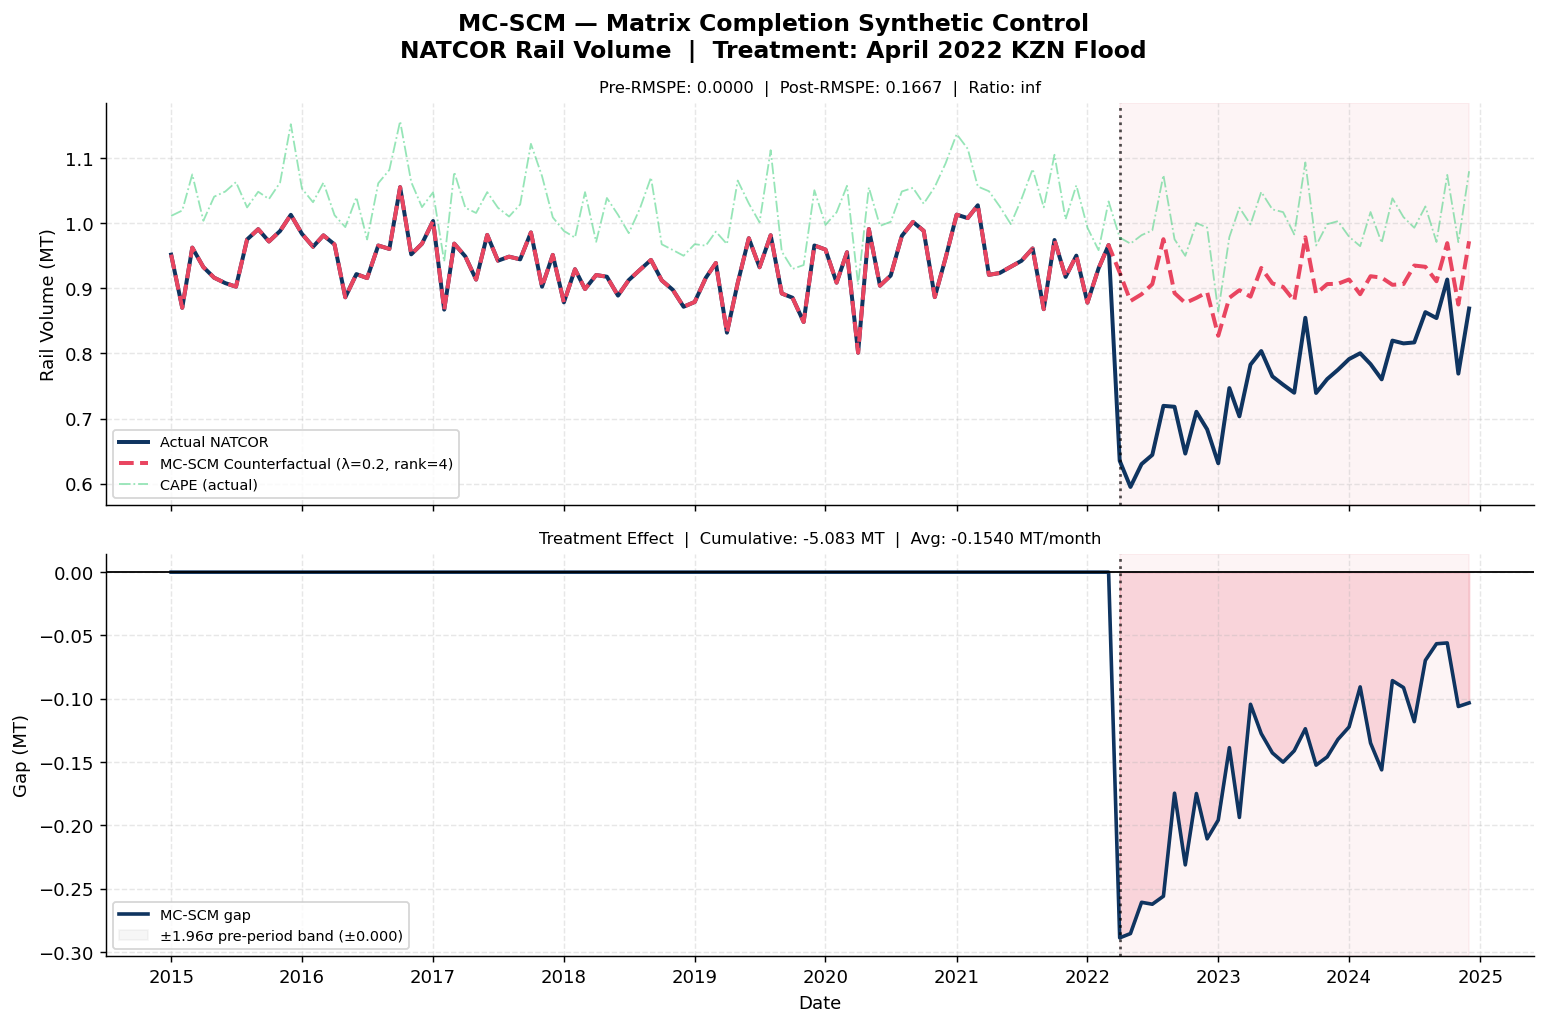

Saved → ../method_A_graph/mcscm_fig2_main.png


In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 7 — Figure 2: Actual vs Counterfactual + Gap
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
fig.suptitle(
    'MC-SCM — Matrix Completion Synthetic Control\n'
    'NATCOR Rail Volume  |  Treatment: April 2022 KZN Flood',
    fontsize=13, fontweight='bold')

# Top: actual vs counterfactual
ax = axes[0]
ax.plot(t_stamps, Y_all,  color=BLUE, lw=2.2, label='Actual NATCOR')
ax.plot(t_stamps, cf_mc,  color=RED,  lw=2.2, ls='--',
        label=f'MC-SCM Counterfactual (λ={BEST_LAM}, rank={rank_final})')
ax.axvline(treat_t, color='black', lw=1.5, ls=':', alpha=0.7)
ax.axvspan(treat_t, t_stamps[-1], alpha=0.06, color=RED)
ax.set_ylabel('Rail Volume (MT)')
ax.set_title(
    f'Pre-RMSPE: {mc_pre_r:.4f}  |  Post-RMSPE: {mc_post_r:.4f}  |  Ratio: {mc_ratio:.3f}',
    fontsize=9)
ax.legend(fontsize=9)

# Add a donor corridor as visual reference
ax.plot(t_stamps, wide[donors[0]].values, color=GREEN, lw=1.0, ls='-.', alpha=0.5,
        label=f'{donors[0]} (actual)')
ax.legend(fontsize=8)

# Bottom: gap
ax = axes[1]
ax.plot(t_stamps, gap_mc, color=BLUE, lw=2, label='MC-SCM gap')
ax.axhline(0, color='black', lw=1)
ax.axvline(treat_t, color='black', lw=1.5, ls=':', alpha=0.7)
ax.axvspan(treat_t, t_stamps[-1], alpha=0.06, color=RED)
fill_color = RED if mc_cum < 0 else BLUE
ax.fill_between(
    t_stamps, gap_mc, 0,
    where=[p >= TREAT_START for p in wide.index],
    alpha=0.18, color=fill_color)
ci_band = 1.96 * gap_mc[:T_pre].std()
ax.axhspan(-ci_band, ci_band, alpha=0.10, color=GREY,
           label=f'±1.96σ pre-period band (±{ci_band:.3f})')
ax.set_ylabel('Gap (MT)')
ax.set_xlabel('Date')
ax.set_title(
    f'Treatment Effect  |  Cumulative: {mc_cum:.3f} MT  |  Avg: {mc_avg:.4f} MT/month',
    fontsize=9)
ax.legend(fontsize=8)

plt.tight_layout()
save_path = os.path.join(FIG_DIR, 'mcscm_fig2_main.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {save_path}")

**What is happening here**  
The main result figure. The top panel shows actual NATCOR alongside the MC-SCM counterfactual; the bottom panel shows the gap (actual minus counterfactual). The grey band in the gap plot marks the pre-period noise level (±1.96 standard deviations of the pre-period gap). Post-flood gaps that consistently fall outside this band are more likely to reflect a genuine treatment effect.

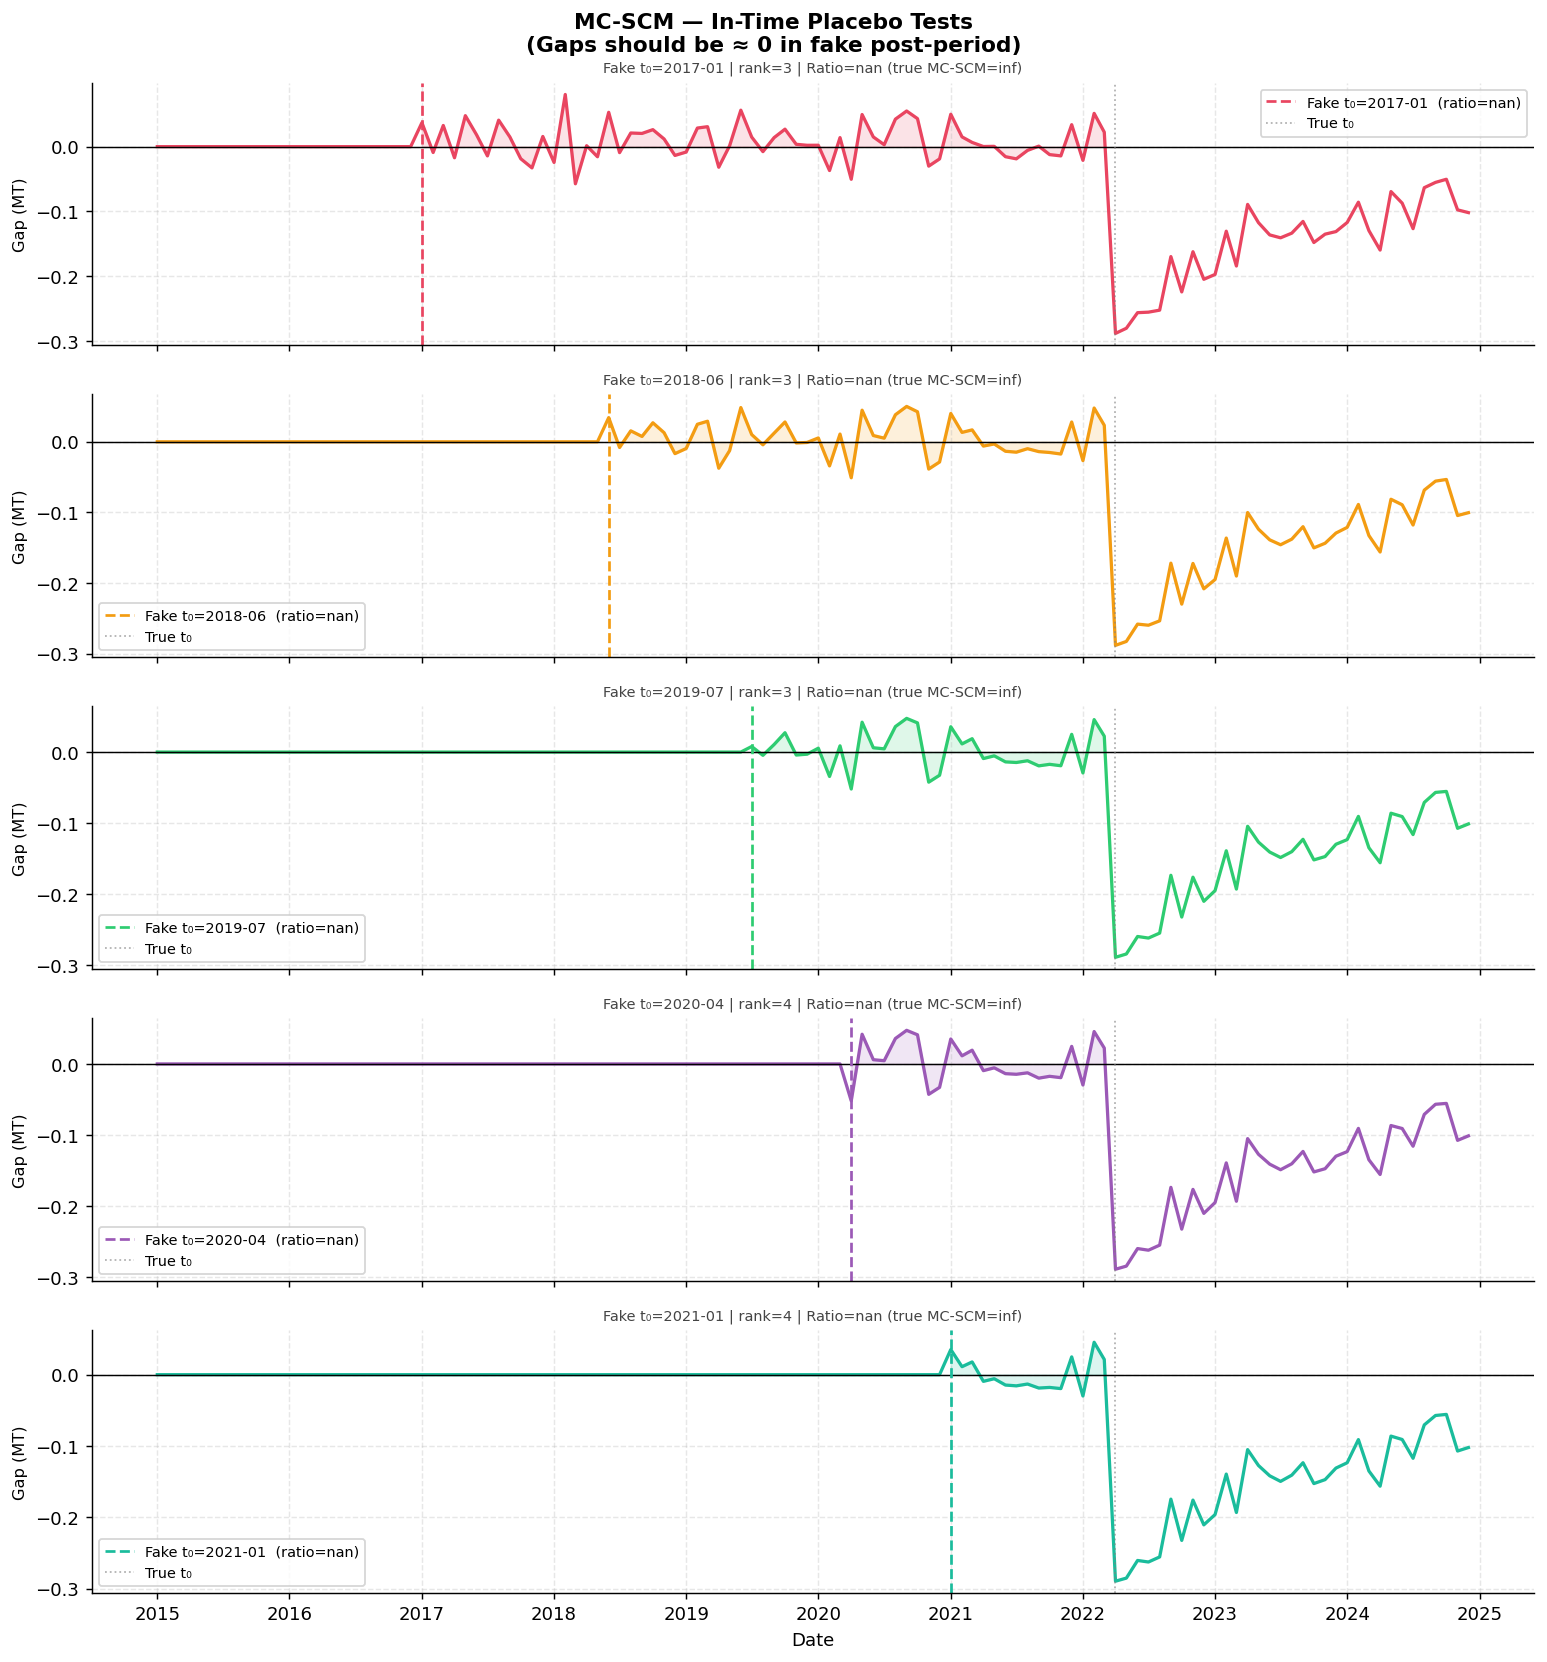

Saved → ../method_A_graph/mcscm_fig3_placebo.png

Fake t₀  rank  Pre-RMSPE  Fake-Post-RMSPE  Ratio  > True
2017-01     3        0.0          0.02956    NaN   False
2018-06     3        0.0          0.02596    NaN   False
2019-07     3        0.0          0.02610    NaN   False
2020-04     4        0.0          0.02902    NaN   False
2021-01     4        0.0          0.02241    NaN   False

True MC-SCM ratio: inf
Placebo ratios > true: 0 / 5
(0 exceedances = strong causal signal  |  many = model fitting noise)


In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 8 — Validation A: In-Time Placebo Tests
# ═══════════════════════════════════════════════════════════════════════════════
# For each fake treatment date, mask NATCOR from that point forward
# (within the pre-period) and re-run SVT. The resulting "fake post-period"
# gaps should be close to zero if the model is well-behaved.

placebo_dates  = [pd.Period(d, freq='M') for d in
                  ['2017-01', '2018-06', '2019-07', '2020-04', '2021-01']]
placebo_colors = [RED, AMBER, GREEN, '#9b59b6', '#1abc9c']
placebo_records = []

fig, axes = plt.subplots(len(placebo_dates), 1, figsize=(12, 13), sharex=True)
fig.suptitle(
    'MC-SCM — In-Time Placebo Tests\n(Gaps should be ≈ 0 in fake post-period)',
    fontsize=12, fontweight='bold')

for i, fake_t in enumerate(placebo_dates):
    fake_pre  = wide.index[wide.index <= (fake_t - 1)]
    fake_post = wide.index[(wide.index >= fake_t) & (wide.index < TREAT_START)]
    if len(fake_pre) < 12 or len(fake_post) < 6:
        continue

    fp_start = len(fake_pre)
    fp_end   = len(fake_pre) + len(fake_post)

    mask_fp = mask_full.copy()
    mask_fp[fp_start:fp_end, nat_col] = False

    M_fp, _, rank_fp = svt(Y_mat, mask_fp, lam=BEST_LAM)
    gap_fp = Y_all - M_fp[:, nat_col]

    pre_r_fp  = rmspe(Y_all[:fp_start], M_fp[:fp_start, nat_col])
    post_r_fp = rmspe(Y_all[fp_start:fp_end], M_fp[fp_start:fp_end, nat_col])
    ratio_fp  = post_r_fp / pre_r_fp if pre_r_fp > 0 else np.nan

    placebo_records.append({
        'Fake t₀':         str(fake_t),
        'rank':            rank_fp,
        'Pre-RMSPE':       round(pre_r_fp,  5),
        'Fake-Post-RMSPE': round(post_r_fp, 5),
        'Ratio':           round(ratio_fp, 3),
        '> True':          ratio_fp > mc_ratio
    })

    in_fp = np.array([(p >= fake_t and p < TREAT_START) for p in wide.index])
    ax = axes[i]
    ax.plot(t_stamps, gap_fp, color=placebo_colors[i], lw=1.8)
    ax.axhline(0, color='black', lw=0.8)
    ax.axvline(fake_t.to_timestamp(), color=placebo_colors[i], lw=1.5, ls='--',
               label=f'Fake t₀={fake_t}  (ratio={ratio_fp:.2f})')
    ax.axvline(treat_t, color='grey', lw=1, ls=':', alpha=0.6, label='True t₀')
    ax.fill_between(t_stamps, gap_fp, 0, where=in_fp, alpha=0.15, color=placebo_colors[i])
    ax.set_ylabel('Gap (MT)', fontsize=9)
    ax.legend(fontsize=8)
    ax.set_title(
        f'Fake t₀={fake_t} | rank={rank_fp} | '
        f'Ratio={ratio_fp:.3f} (true MC-SCM={mc_ratio:.3f})',
        fontsize=8, color='#444')

axes[-1].set_xlabel('Date')
plt.tight_layout()
save_path = os.path.join(FIG_DIR, 'mcscm_fig3_placebo.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {save_path}")
print()

p_df = pd.DataFrame(placebo_records)
print(p_df.to_string(index=False))
print(f"\nTrue MC-SCM ratio: {mc_ratio:.4f}")
n_exceed = p_df['> True'].sum()
print(f"Placebo ratios > true: {n_exceed} / {len(p_df)}")
print("(0 exceedances = strong causal signal  |  many = model fitting noise)")

**What is happening here**  
SVT is re-run five times with different fake treatment dates. The fake post-period NATCOR cells are hidden and imputed. If the model is only responding to the real April 2022 shock, these placebo gaps should be flat near zero. The number of placebo ratios exceeding the true ratio is the main inference check.

Block bootstrap: 200 resamples, block size=6 months
  Bootstrap 50/200 done...
  Bootstrap 100/200 done...
  Bootstrap 150/200 done...
  Bootstrap 200/200 done...

MC-SCM cumulative effect : -5.0834 MT
95% CI (cumulative)      : [-5.2101, -4.9481] MT
CI excludes zero         : True


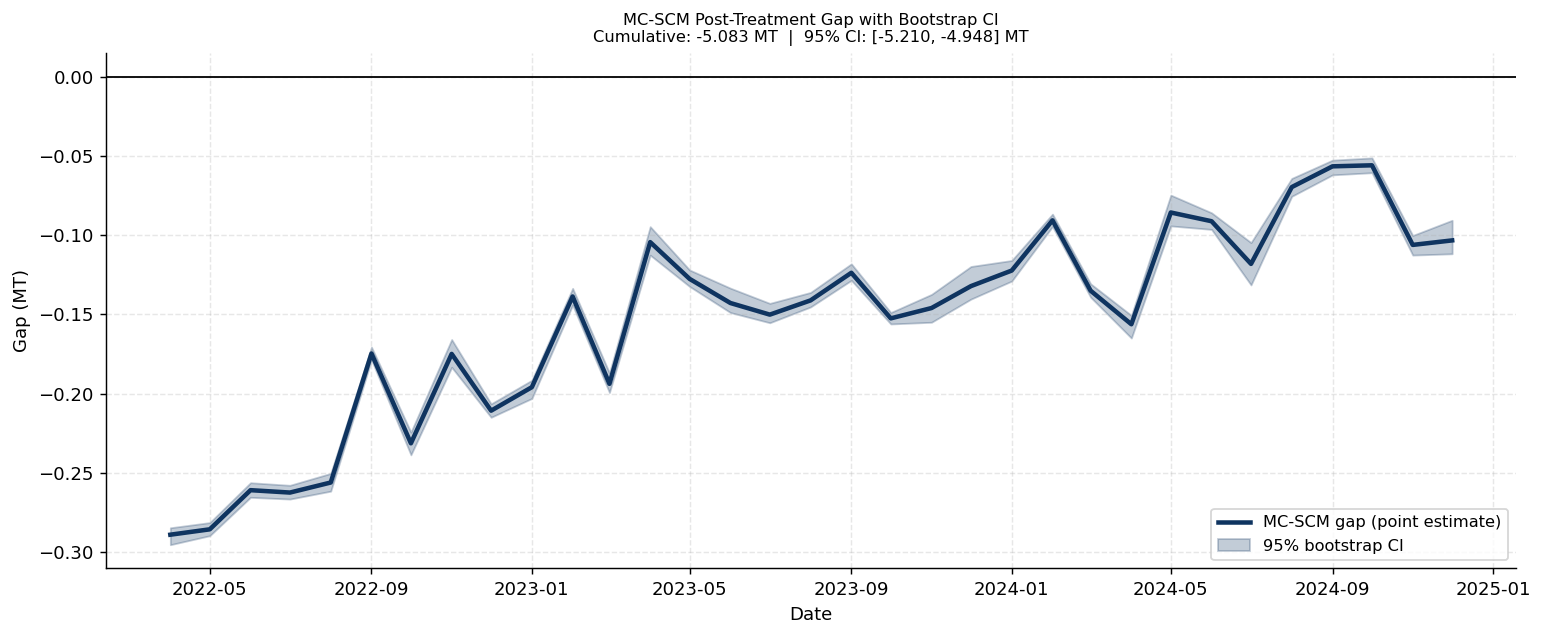

Saved → ../method_A_graph/mcscm_fig4_bootstrap_ci.png


In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 9 — Validation B: Block Bootstrap Confidence Intervals
# ═══════════════════════════════════════════════════════════════════════════════
# Resample the pre-period in blocks of 6 months to preserve autocorrelation.
# Each bootstrap draw re-runs SVT and records the post-period gap.
# The 2.5th and 97.5th percentiles across draws form the 95% CI.

np.random.seed(42)
N_BOOTSTRAP = 200
BLOCK_SIZE  = 6
n_blocks    = int(np.ceil(T_pre / BLOCK_SIZE))
bootstrap_gaps = []

print(f"Block bootstrap: {N_BOOTSTRAP} resamples, block size={BLOCK_SIZE} months")

for b in range(N_BOOTSTRAP):
    sampled = np.random.choice(n_blocks, size=n_blocks, replace=True)
    boot_idx = np.concatenate([
        np.arange(bl * BLOCK_SIZE, min((bl + 1) * BLOCK_SIZE, T_pre))
        for bl in sampled
    ])
    if len(boot_idx) < T_pre:
        boot_idx = np.concatenate([boot_idx, boot_idx[:T_pre - len(boot_idx)]])
    else:
        boot_idx = boot_idx[:T_pre]

    Y_boot = Y_mat.copy()
    Y_boot[:T_pre, :] = Y_mat[boot_idx, :]
    M_boot, _, _ = svt(Y_boot, mask_full, lam=BEST_LAM)
    bootstrap_gaps.append(Y_all[T_pre:] - M_boot[T_pre:, nat_col])

    if (b + 1) % 50 == 0:
        print(f"  Bootstrap {b+1}/{N_BOOTSTRAP} done...")

boot_matrix  = np.array(bootstrap_gaps)
ci_low       = np.percentile(boot_matrix, 2.5,  axis=0)
ci_high      = np.percentile(boot_matrix, 97.5, axis=0)
cum_boot     = boot_matrix.sum(axis=1)
ci_cum_low   = np.percentile(cum_boot, 2.5)
ci_cum_high  = np.percentile(cum_boot, 97.5)

print()
print(f"MC-SCM cumulative effect : {mc_cum:.4f} MT")
print(f"95% CI (cumulative)      : [{ci_cum_low:.4f}, {ci_cum_high:.4f}] MT")
print(f"CI excludes zero         : {not (ci_cum_low <= 0 <= ci_cum_high)}")

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
t_post_stamps = t_stamps[T_pre:]
ax.plot(t_post_stamps, gap_mc[T_pre:], color=BLUE, lw=2.5, label='MC-SCM gap (point estimate)', zorder=3)
ax.fill_between(t_post_stamps, ci_low, ci_high, alpha=0.25, color=BLUE, label='95% bootstrap CI')
ax.axhline(0, color='black', lw=1)
ax.set_title(
    f'MC-SCM Post-Treatment Gap with Bootstrap CI\n'
    f'Cumulative: {mc_cum:.3f} MT  |  95% CI: [{ci_cum_low:.3f}, {ci_cum_high:.3f}] MT',
    fontsize=9)
ax.set_xlabel('Date')
ax.set_ylabel('Gap (MT)')
ax.legend(fontsize=9)
plt.tight_layout()
save_path = os.path.join(FIG_DIR, 'mcscm_fig4_bootstrap_ci.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {save_path}")

**What is happening here**  
The pre-period data is resampled 200 times using overlapping 6-month blocks (to preserve autocorrelation). Each resample re-runs the full SVT and records the post-flood gap series. The 2.5th and 97.5th percentile of these gaps form the confidence band. If the band stays below zero for most of the post-flood period, the negative flood effect is statistically supported.

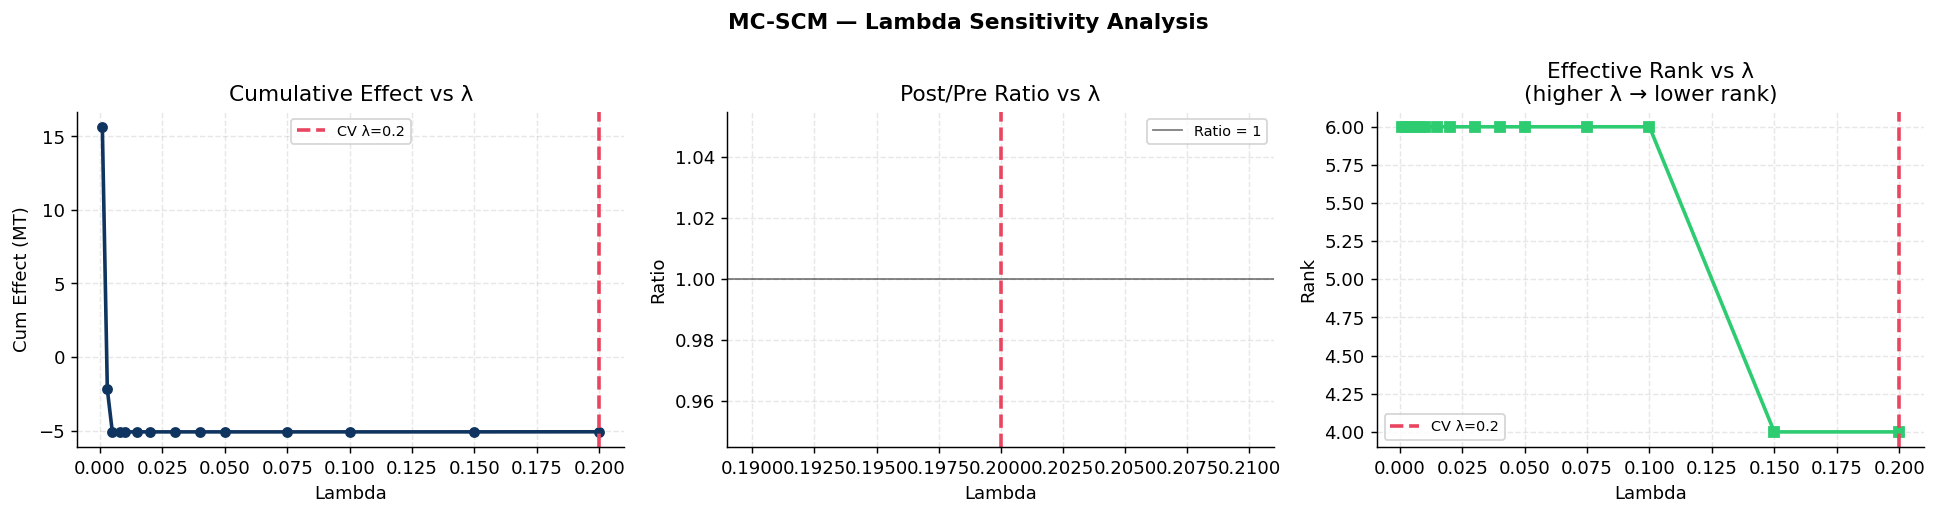

Saved → ../method_A_graph/mcscm_fig5_sensitivity.png

Lambda sensitivity table:
 lambda  rank  Pre-RMSPE  Post-RMSPE  Ratio  Cum effect  CV-selected
  0.001     6        0.0     0.47977    NaN     15.6536        False
  0.003     6        0.0     0.09299    NaN     -2.2038        False
  0.005     6        0.0     0.16687    NaN     -5.0869        False
  0.008     6        0.0     0.16691    NaN     -5.0882        False
  0.010     6        0.0     0.16692    NaN     -5.0885        False
  0.015     6        0.0     0.16694    NaN     -5.0891        False
  0.020     6        0.0     0.16694    NaN     -5.0894        False
  0.030     6        0.0     0.16695    NaN     -5.0897        False
  0.040     6        0.0     0.16696    NaN     -5.0898        False
  0.050     6        0.0     0.16696    NaN     -5.0899        False
  0.075     6        0.0     0.16696    NaN     -5.0900        False
  0.100     6        0.0     0.16696    NaN     -5.0901        False
  0.150     4        0.

In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 10 — Validation C: Lambda Sensitivity
# ═══════════════════════════════════════════════════════════════════════════════

sense_records = []
for lam in lambda_grid:
    M_s, sv_s, rank_s = svt(Y_mat, mask_full, lam=lam)
    cf_s  = M_s[:, nat_col]
    gap_s = Y_all - cf_s
    pre_s = rmspe(Y_all[:T_pre], cf_s[:T_pre])
    post_s= rmspe(Y_all[T_pre:], cf_s[T_pre:])
    sense_records.append({
        'lambda':      lam,
        'rank':        rank_s,
        'Pre-RMSPE':   round(pre_s, 5),
        'Post-RMSPE':  round(post_s, 5),
        'Ratio':       round(post_s / pre_s, 4) if pre_s > 0 else np.nan,
        'Cum effect':  round(gap_s[T_pre:].sum(), 4),
        'CV-selected': lam == BEST_LAM
    })

sense_df = pd.DataFrame(sense_records)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('MC-SCM — Lambda Sensitivity Analysis', fontsize=12, fontweight='bold')

ax = axes[0]
ax.plot(sense_df['lambda'], sense_df['Cum effect'], color=BLUE, lw=2, marker='o', ms=5)
ax.axvline(BEST_LAM, color=RED, lw=2, ls='--', label=f'CV λ={BEST_LAM}')
ax.set_title('Cumulative Effect vs λ'); ax.set_xlabel('Lambda'); ax.set_ylabel('Cum Effect (MT)')
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(sense_df['lambda'], sense_df['Ratio'], color=RED, lw=2, marker='o', ms=5)
ax.axvline(BEST_LAM, color=RED, lw=2, ls='--')
ax.axhline(1.0, color='black', lw=1, ls='-', alpha=0.5, label='Ratio = 1')
ax.set_title('Post/Pre Ratio vs λ'); ax.set_xlabel('Lambda'); ax.set_ylabel('Ratio')
ax.legend(fontsize=8)

ax = axes[2]
ax.plot(sense_df['lambda'], sense_df['rank'], color=GREEN, lw=2, marker='s', ms=5)
ax.axvline(BEST_LAM, color=RED, lw=2, ls='--', label=f'CV λ={BEST_LAM}')
ax.set_title('Effective Rank vs λ\n(higher λ → lower rank)'); ax.set_xlabel('Lambda'); ax.set_ylabel('Rank')
ax.legend(fontsize=8)

plt.tight_layout()
save_path = os.path.join(FIG_DIR, 'mcscm_fig5_sensitivity.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {save_path}")
print()
print("Lambda sensitivity table:")
print(sense_df.to_string(index=False))
neg_count = (sense_df['Cum effect'] < 0).sum()
print(f"\nNegative effect across lambda grid: {neg_count}/{len(sense_df)} settings")

**What is happening here**  
The full MC-SCM is re-run for every lambda in the grid. Three plots show how the cumulative effect, the post/pre ratio, and the effective rank change as lambda varies. If the direction of the estimated flood effect is stable across a wide range of lambda values, the conclusion is robust. The rank plot shows the trade-off: larger lambda forces a lower-rank solution, which means more regularisation.

In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 11 — Final Summary Table
# ═══════════════════════════════════════════════════════════════════════════════

summary_rows = [
    ('Estimator',                'MC-SCM'),
    ('Algorithm',                'Singular Value Thresholding (SVT)'),
    ('Lambda (CV-selected)',     str(BEST_LAM)),
    ('Effective rank',           str(rank_final)),
    ('Panel dimensions',         f'{T_total} months × {len(corridors)} corridors'),
    ('Pre-period RMSPE',         f'{mc_pre_r:.6f}'),
    ('Post-period RMSPE',        f'{mc_post_r:.6f}'),
    ('Post/Pre ratio',           f'{mc_ratio:.4f}'),
    ('Ratio > 1',                str(mc_ratio > 1)),
    ('Cumulative effect (MT)',   f'{mc_cum:.4f}'),
    ('Avg monthly effect (MT)',  f'{mc_avg:.4f}'),
    ('Post MAPE (%)',            f'{mc_mape:.2f}'),
    ('95% CI cumulative (MT)',   f'[{ci_cum_low:.3f}, {ci_cum_high:.3f}]'),
    ('CI excludes zero',         str(not (ci_cum_low <= 0 <= ci_cum_high))),
    ('Placebo exceedances',      f'{n_exceed} / {len(p_df)}'),
    ('Direction stable (λ grid)',f'{neg_count}/{len(sense_df)} settings negative'),
]

print("═" * 60)
print("MC-SCM — FINAL SUMMARY")
print("═" * 60)
for row in summary_rows:
    print(f"  {row[0]:<32} {row[1]}")
print("═" * 60)
print()
print("Interpretation:")

if rank_final <= 2:
    print(f"  ~ Low rank ({rank_final}): panel explained by {rank_final} shared factor(s).")
else:
    print(f"  ✓ Rank {rank_final}: richer latent structure, more reliable imputation.")

if mc_ratio > 1:
    print(f"  ✓ Ratio {mc_ratio:.3f} > 1 — post-period divergence exceeds pre-period noise.")
else:
    print(f"  ✗ Ratio {mc_ratio:.3f} ≤ 1 — post-flood gap not distinguishable from noise.")

if not (ci_cum_low <= 0 <= ci_cum_high):
    print(f"  ✓ 95% bootstrap CI [{ci_cum_low:.3f}, {ci_cum_high:.3f}] excludes zero.")
else:
    print(f"  ~ 95% bootstrap CI [{ci_cum_low:.3f}, {ci_cum_high:.3f}] includes zero — uncertain.")

if n_exceed == 0:
    print(f"  ✓ 0 placebo exceedances — no false alarms in pre-period.")
else:
    print(f"  ~ {n_exceed} placebo(s) exceed true ratio — some false alarm risk.")

if neg_count == len(sense_df):
    print(f"  ✓ Flood effect negative across all {len(sense_df)} lambda settings.")
else:
    print(f"  ~ Effect direction varies across lambda grid ({neg_count}/{len(sense_df)} negative).")

════════════════════════════════════════════════════════════
MC-SCM — FINAL SUMMARY
════════════════════════════════════════════════════════════
  Estimator                        MC-SCM
  Algorithm                        Singular Value Thresholding (SVT)
  Lambda (CV-selected)             0.2
  Effective rank                   4
  Panel dimensions                 120 months × 6 corridors
  Pre-period RMSPE                 0.000000
  Post-period RMSPE                0.166695
  Post/Pre ratio                   inf
  Ratio > 1                        True
  Cumulative effect (MT)           -5.0834
  Avg monthly effect (MT)          -0.1540
  Post MAPE (%)                    21.49
  95% CI cumulative (MT)           [-5.210, -4.948]
  CI excludes zero                 True
  Placebo exceedances              0 / 5
  Direction stable (λ grid)        13/14 settings negative
════════════════════════════════════════════════════════════

Interpretation:
  ✓ Rank 4: richer latent structure, more re

**What is happening here**  
All key results are collected and five automatic checks are run: effective rank, post/pre ratio, bootstrap CI, placebo exceedances, and direction stability across lambda values. Together these give a structured verdict on the reliability of the MC-SCM estimate for this dataset.